<a href="https://colab.research.google.com/github/Nkeh/ml-algorithms/blob/main/logistic_regression_diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 2: Diabetes Classification — Logistic Regression

**Course ML Project | Model 2 of 4**

---

### Pipeline
1. Scope & Problem Definition
2. Data Acquisition
3. Cleaning & Preprocessing
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. **Model Selection** ← the key step
7. Model Training
8. Evaluation & Tuning
9. PCA Extension

---
## Step 1 — Scope & Problem Definition

**Goal:** Predict whether a patient has diabetes (yes/no) based on diagnostic measurements.

| Property | Detail |
|---|---|
| Task type | Supervised **binary classification** |
| Target variable | `Outcome` — 0 (no diabetes) or 1 (diabetes) |
| Input features | Medical measurements: glucose, BMI, insulin, age, etc. |
| Dataset | Pima Indians Diabetes Dataset (768 patients, 8 features) |

The output is **binary and categorical** — not a real number. This immediately rules out linear regression. We need a model that outputs a **probability between 0 and 1**, which we then threshold at 0.5 to get a class label.

This is the core reason logistic regression is the right model here. It models:

$$P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^T \mathbf{x} + b)}}$$

The sigmoid function $\sigma(\cdot)$ squashes any real-valued score into $(0, 1)$ — a valid probability.

---
## Step 2 — Data Acquisition

We use the **Pima Indians Diabetes Dataset**, originally from the National Institute of Diabetes and Digestive and Kidney Diseases. It contains diagnostic data for 768 adult female Pima Indian patients, all aged ≥21.

| Feature | Description |
|---|---|
| `Pregnancies` | Number of pregnancies |
| `Glucose` | Plasma glucose concentration (2-hour oral glucose tolerance test) |
| `BloodPressure` | Diastolic blood pressure (mm Hg) |
| `SkinThickness` | Triceps skin fold thickness (mm) |
| `Insulin` | 2-hour serum insulin (μU/mL) |
| `BMI` | Body mass index (weight kg / height m²) |
| `DiabetesPedigreeFunction` | Genetic diabetes risk score based on family history |
| `Age` | Age in years |
| `Outcome` | **Target: 1 = diabetes, 0 = no diabetes** |

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

BLUE  = '#378ADD'
CORAL = '#D85A30'
TEAL  = '#1D9E75'
AMBER = '#BA7517'
PURP  = '#7F77DD'
GRAY  = '#888780'

print('Libraries loaded.')

Libraries loaded.


In [ ]:
# ── Load data ─────────────────────────────────────────────────────────────────
URL = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'
df_raw = pd.read_csv(URL)

print(f'Shape: {df_raw.shape}')
print(f'\nColumns: {df_raw.columns.tolist()}')
print(f'\nClass balance:\n{df_raw["Outcome"].value_counts()}')
print(f'\nFirst 5 rows:')
df_raw.head()

Shape: (768, 9)

Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Class balance:
Outcome
0    500
1    268
Name: count, dtype: int64

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---
## Step 3 — Cleaning & Preprocessing

**Key issue:** Several columns use `0` as a placeholder for missing values. A glucose reading of 0, a BMI of 0, or a blood pressure of 0 are physiologically impossible. These are actually missing values disguised as zeros.

Affected columns: `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`.

We replace zeros in these columns with the **column median** (robust to outliers). `Pregnancies` and `Age` can legitimately be 0 or any positive integer — we leave them alone.

We also check for class imbalance. If one class is much rarer than the other, the model can achieve high accuracy by always predicting the majority class — without learning anything useful.

In [ ]:
# ── Working copy ──────────────────────────────────────────────────────────────
df = df_raw.copy()

# ── Replace physiologically impossible zeros with median ──────────────────────
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Zero counts before imputation:')
for col in zero_cols:
    n_zeros = (df[col] == 0).sum()
    print(f'  {col:<28} {n_zeros} zeros ({n_zeros/len(df)*100:.1f}%)')

for col in zero_cols:
    median_val = df[col].replace(0, np.nan).median()
    df[col]    = df[col].replace(0, median_val)

print(f'\nMissing values after imputation: {df.isnull().sum().sum()}')

# ── Class balance ─────────────────────────────────────────────────────────────
class_counts = df['Outcome'].value_counts()
print(f'\nClass balance:')
print(f'  No diabetes (0): {class_counts[0]}  ({class_counts[0]/len(df)*100:.1f}%)')
print(f'  Diabetes    (1): {class_counts[1]}  ({class_counts[1]/len(df)*100:.1f}%)')
print(f'\nImbalance ratio: {class_counts[0]/class_counts[1]:.2f}:1')
print('  → Mild imbalance. We will use class_weight="balanced" in the model.')

Zero counts before imputation:
  Glucose                      5 zeros (0.7%)
  BloodPressure                35 zeros (4.6%)
  SkinThickness                227 zeros (29.6%)
  Insulin                      374 zeros (48.7%)
  BMI                          11 zeros (1.4%)

Missing values after imputation: 0

Class balance:
  No diabetes (0): 500  (65.1%)
  Diabetes    (1): 268  (34.9%)

Imbalance ratio: 1.87:1
  → Mild imbalance. We will use class_weight="balanced" in the model.


---
## Step 4 — Exploratory Data Analysis (EDA)

We look at:
- Distribution of each feature, split by class
- Correlation between features
- Which features appear most separable between diabetic and non-diabetic patients

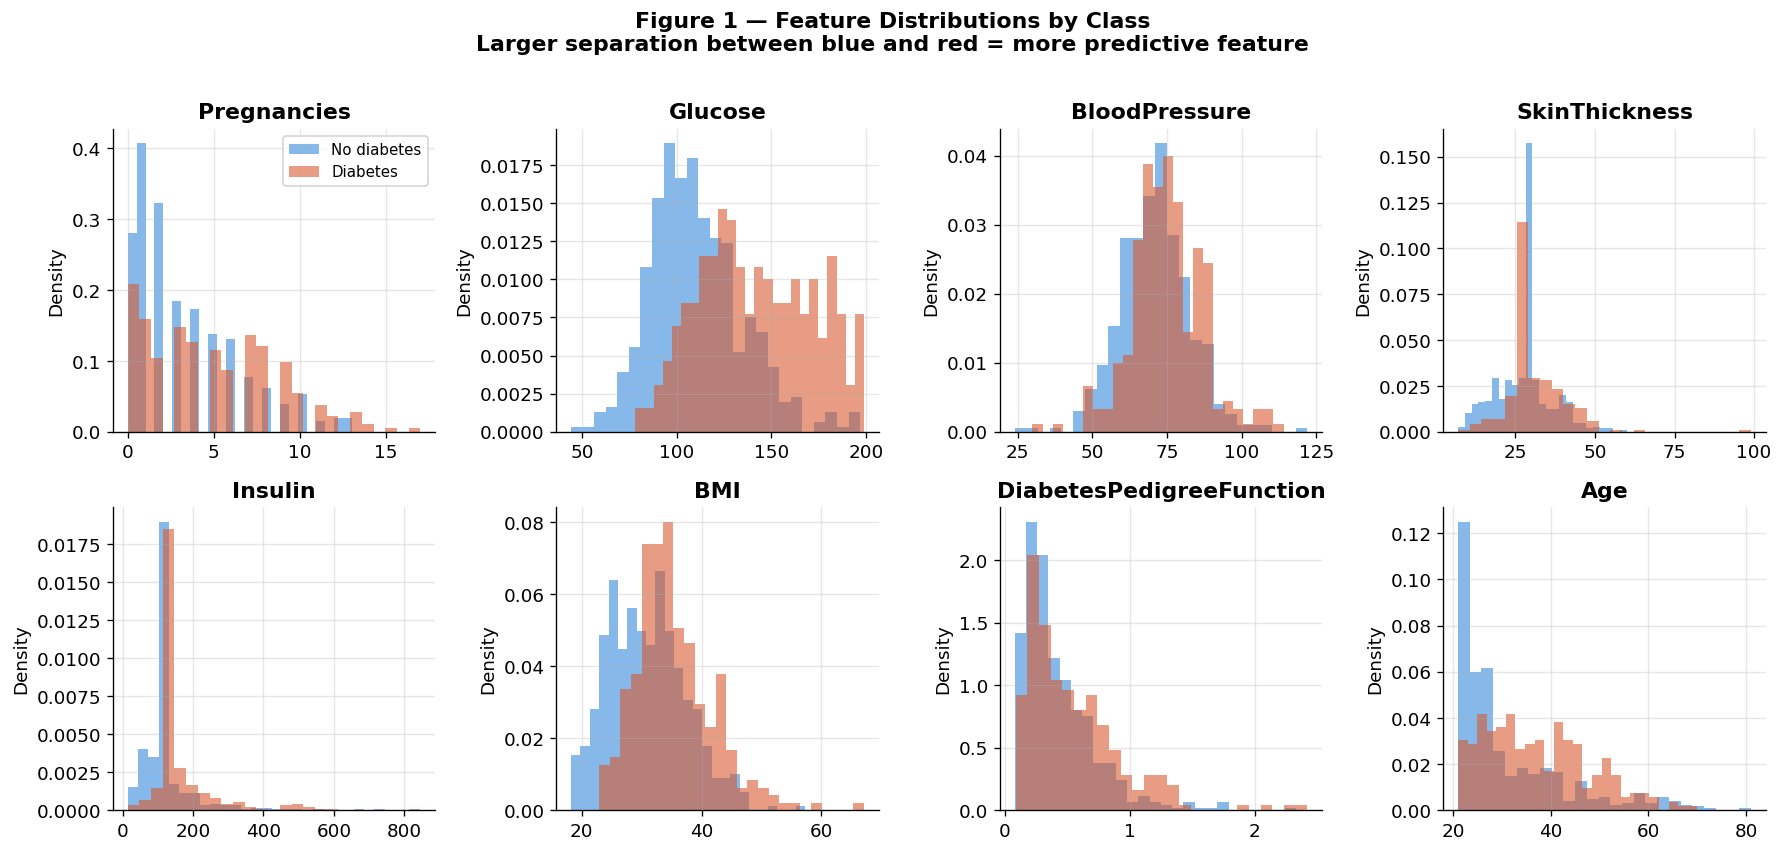

In [ ]:
# ── 4a. Feature distributions by class ───────────────────────────────────────
FEATURES = [c for c in df.columns if c != 'Outcome']

fig, axes = plt.subplots(2, 4, figsize=(15, 7))
axes = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes[i]
    ax.hist(df[df['Outcome']==0][feat], bins=25, alpha=0.6,
            color=BLUE,  label='No diabetes', density=True)
    ax.hist(df[df['Outcome']==1][feat], bins=25, alpha=0.6,
            color=CORAL, label='Diabetes',    density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Density')
    if i == 0:
        ax.legend(fontsize=9)

plt.suptitle('Figure 1 — Feature Distributions by Class\n'
             'Larger separation between blue and red = more predictive feature',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

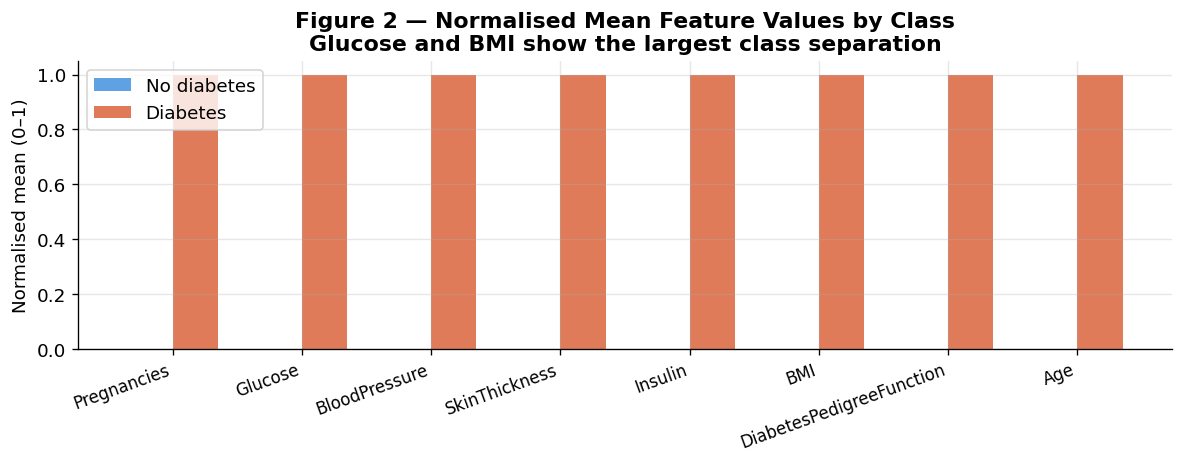

Mann-Whitney U test (feature significance between classes):
  Feature                            U-stat      p-value  Significant
  ------------------------------------------------------------------
  Pregnancies                         50985     3.75e-08      YES ***
  Glucose                             27934     1.51e-40      YES ***
  BloodPressure                       53158     2.23e-06      YES ***
  SkinThickness                       49780     2.32e-09      YES ***
  Insulin                             46098     2.96e-14      YES ***
  BMI                                 42082     1.84e-17      YES ***
  DiabetesPedigreeFunction            52769     1.20e-06      YES ***
  Age                                 41950     1.14e-17      YES ***


In [ ]:
# ── 4b. Mean feature values by class (normalised) ─────────────────────────────
means = df.groupby('Outcome')[FEATURES].mean()
means_norm = (means - means.min()) / (means.max() - means.min())  # 0-1 scale

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(FEATURES))
w = 0.35
ax.bar(x - w/2, means_norm.loc[0], w, color=BLUE,  alpha=0.8, label='No diabetes')
ax.bar(x + w/2, means_norm.loc[1], w, color=CORAL, alpha=0.8, label='Diabetes')
ax.set_xticks(x)
ax.set_xticklabels(FEATURES, rotation=20, ha='right', fontsize=10)
ax.set_title('Figure 2 — Normalised Mean Feature Values by Class\n'
             'Glucose and BMI show the largest class separation',
             fontweight='bold')
ax.set_ylabel('Normalised mean (0–1)')
ax.legend()
plt.tight_layout()
plt.show()

# Mann-Whitney U test — which features differ significantly between classes?
print('Mann-Whitney U test (feature significance between classes):')
print(f'  {"Feature":<30} {"U-stat":>10} {"p-value":>12} {"Significant":>12}')
print('  ' + '-'*66)
for feat in FEATURES:
    grp0 = df[df['Outcome']==0][feat]
    grp1 = df[df['Outcome']==1][feat]
    u, p = stats.mannwhitneyu(grp0, grp1, alternative='two-sided')
    sig  = 'YES ***' if p < 0.001 else ('YES *' if p < 0.05 else 'No')
    print(f'  {feat:<30} {u:>10.0f} {p:>12.2e} {sig:>12}')

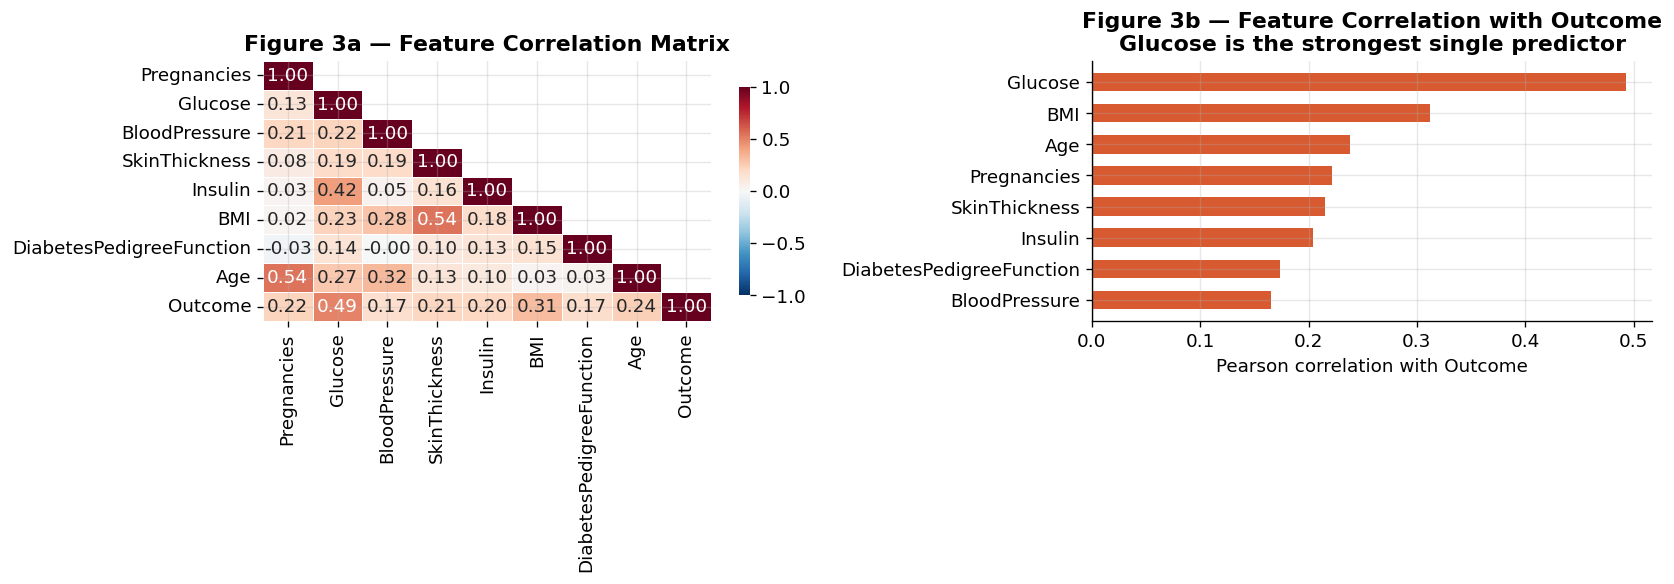

In [ ]:
# ── 4c. Correlation heatmap ───────────────────────────────────────────────────
corr = df[FEATURES + ['Outcome']].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Figure 3a — Feature Correlation Matrix', fontweight='bold')

# Correlation with target only
target_corr = corr['Outcome'].drop('Outcome').sort_values()
colors = [CORAL if v > 0 else BLUE for v in target_corr]
axes[1].barh(target_corr.index, target_corr.values,
             color=colors, edgecolor='none', height=0.6)
axes[1].axvline(0, color=GRAY, linewidth=0.8)
axes[1].set_title('Figure 3b — Feature Correlation with Outcome\n'
                  'Glucose is the strongest single predictor', fontweight='bold')
axes[1].set_xlabel('Pearson correlation with Outcome')

plt.tight_layout()
plt.show()

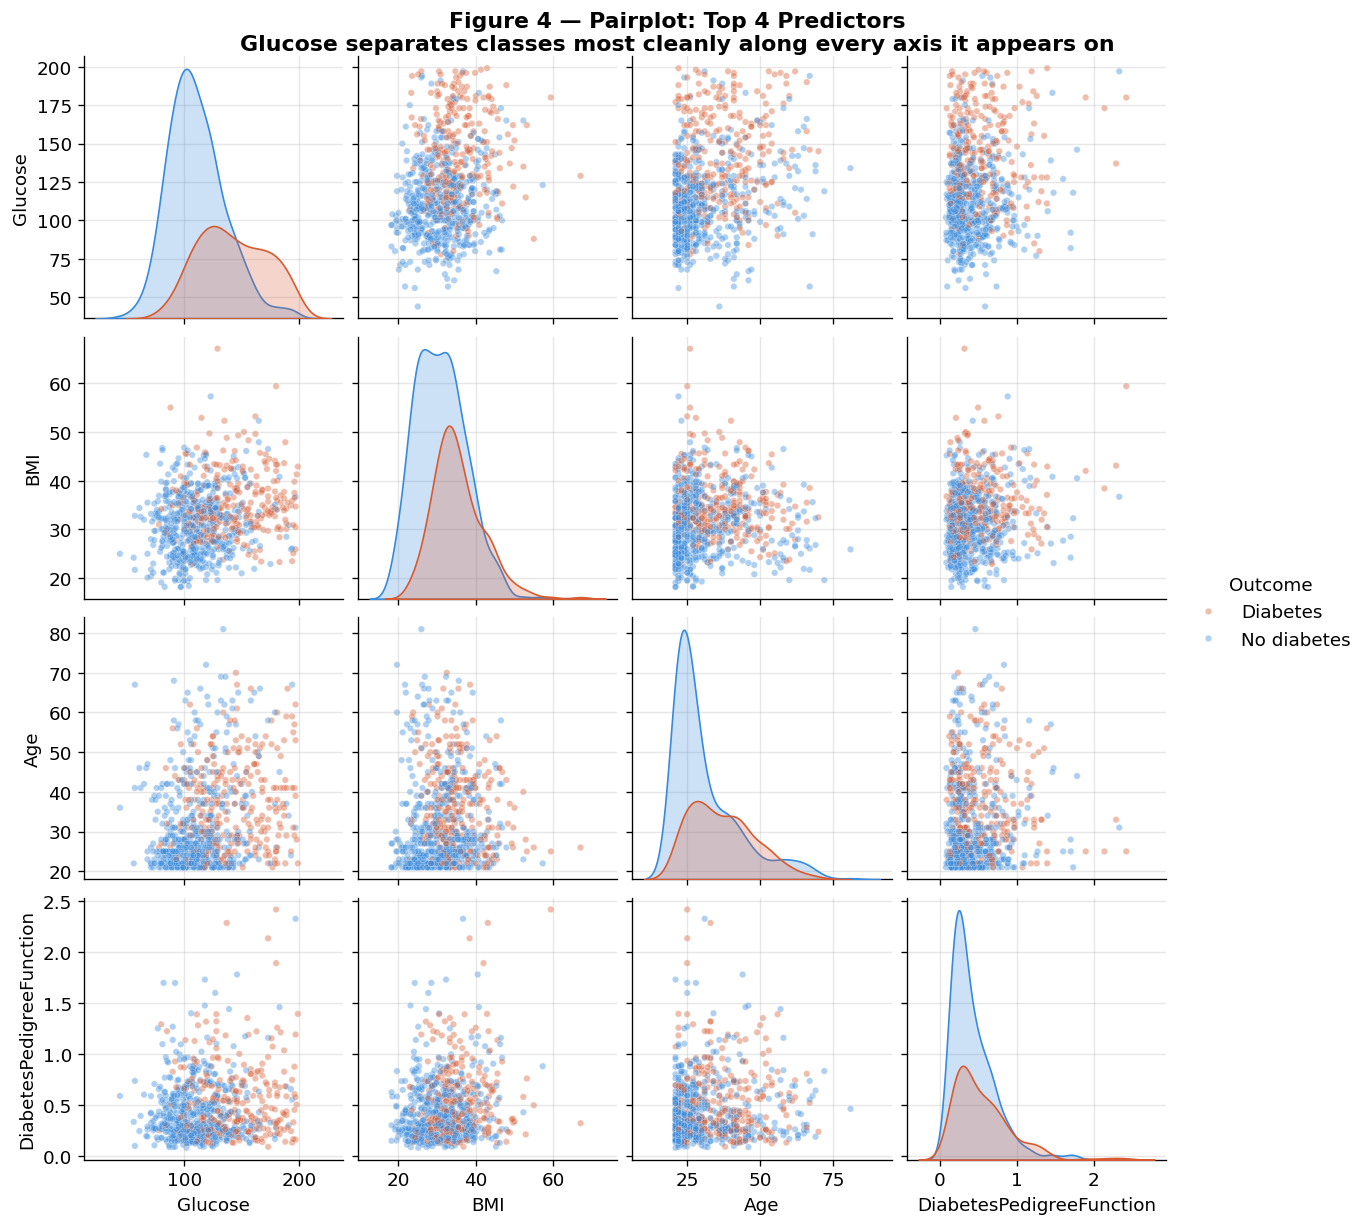

In [ ]:
# ── 4d. Pairplot for top 4 features ──────────────────────────────────────────
top4 = ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction']
pair_df = df[top4 + ['Outcome']].copy()
pair_df['Outcome'] = pair_df['Outcome'].map({0: 'No diabetes', 1: 'Diabetes'})

g = sns.pairplot(pair_df, hue='Outcome',
                 palette={'No diabetes': BLUE, 'Diabetes': CORAL},
                 plot_kws={'alpha': 0.4, 's': 15},
                 diag_kind='kde')
g.figure.suptitle('Figure 4 — Pairplot: Top 4 Predictors\n'
                  'Glucose separates classes most cleanly along every axis it appears on',
                  y=1.02, fontweight='bold')
plt.show()

---
## Step 5 — Feature Engineering

We create clinically meaningful features that may capture signal not present in the raw columns:

| New Feature | Formula | Clinical rationale |
|---|---|---|
| `GlucoseCategory` | Glucose < 100 → 0, 100–125 → 1, ≥126 → 2 | Standard clinical pre-diabetes / diabetes thresholds |
| `BMICategory` | BMI < 18.5 → 0, 18.5–25 → 1, 25–30 → 2, ≥30 → 3 | WHO obesity classification |
| `Glucose_BMI` | Glucose × BMI | Interaction term — high glucose combined with obesity is a known risk |
| `InsulinResistance` | Glucose / (Insulin + 1) | Proxy for insulin resistance: high glucose with low insulin |
| `AgePedigree` | Age × DiabetesPedigreeFunction | Older patients with high genetic risk score |

These are **domain-driven** features — they embed medical knowledge into the model.

In [ ]:
# ── Feature engineering ───────────────────────────────────────────────────────
df['GlucoseCategory']    = pd.cut(df['Glucose'],
                                   bins=[0, 99, 125, 999],
                                   labels=[0, 1, 2]).astype(float)
df['BMICategory']        = pd.cut(df['BMI'],
                                   bins=[0, 18.5, 25, 30, 999],
                                   labels=[0, 1, 2, 3]).astype(float)
df['Glucose_BMI']        = df['Glucose'] * df['BMI']
df['InsulinResistance']  = df['Glucose'] / (df['Insulin'] + 1)
df['AgePedigree']        = df['Age'] * df['DiabetesPedigreeFunction']

ENG_FEATURES = FEATURES + ['GlucoseCategory', 'BMICategory',
                             'Glucose_BMI', 'InsulinResistance', 'AgePedigree']

print(f'Original features:    {len(FEATURES)}')
print(f'Engineered features:  {len(ENG_FEATURES)}')
df[['GlucoseCategory', 'BMICategory',
    'Glucose_BMI', 'InsulinResistance', 'AgePedigree']].describe().round(2)

Original features:    8
Engineered features:  13


,GlucoseCategory,BMICategory,Glucose_BMI,InsulinResistance,AgePedigree
count,768.00,768.00,768.00,768.00,768.00
mean,1.14,2.47,3996.67,1.05,15.82
std,0.79,0.75,1469.66,0.68,12.93
min,0.00,0.00,1100.00,0.21,1.64
25%,0.75,2.00,2924.10,0.75,7.27
50%,1.00,3.00,3750.15,0.94,11.41
75%,2.00,3.00,4800.25,1.18,19.36
max,2.00,3.00,10692.00,12.00,82.14


---
## Step 6 — Model Selection (the key step)

### Why Logistic Regression — and not Linear Regression?

Suppose we naively applied **linear regression** to this binary target:

$$\hat{y} = \mathbf{w}^T \mathbf{x} + b$$

Nothing stops $\hat{y}$ from being 1.7 or −0.3. These values are meaningless as probabilities. We cannot interpret them as $P(\text{diabetes})$.

### 6.1 — The sigmoid function

Logistic regression fixes this by passing the linear combination through the **sigmoid (logistic) function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}} \quad \text{where } z = \mathbf{w}^T \mathbf{x} + b$$

Properties of $\sigma(z)$:
- $\sigma(z) \in (0, 1)$ for all $z \in \mathbb{R}$ — always a valid probability
- $\sigma(0) = 0.5$ — the decision boundary is where $z = 0$
- $\sigma(-z) = 1 - \sigma(z)$ — symmetric around 0.5
- As $z \to +\infty$: $\sigma(z) \to 1$; as $z \to -\infty$: $\sigma(z) \to 0$

### 6.2 — The loss function: Binary Cross-Entropy (Log Loss)

We do NOT use MSE for classification. Instead we minimise **binary cross-entropy**:

$$\mathcal{L}(\mathbf{w}) = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i) \right]$$

where $\hat{p}_i = \sigma(\mathbf{w}^T \mathbf{x}_i + b)$.

**Why not MSE?**
- MSE applied to a sigmoid output gives a **non-convex** loss surface — gradient descent can get stuck in local minima.
- Cross-entropy gives a **convex** loss surface — one global minimum, guaranteed convergence.
- Cross-entropy also has a natural probabilistic interpretation: it is the negative log-likelihood of the Bernoulli distribution.

### 6.3 — The decision boundary

We predict class 1 when $\hat{p} \geq 0.5$, i.e. when $\sigma(z) \geq 0.5$, i.e. when $z \geq 0$:

$$\text{Predict 1 if: } \mathbf{w}^T \mathbf{x} + b \geq 0$$

This is a **linear decision boundary** — a hyperplane in feature space. For two features, it's a straight line.

### 6.4 — The gradient

The gradient of the cross-entropy loss with respect to $\mathbf{w}$ is elegantly simple:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \frac{1}{n} X^T (\hat{\mathbf{p}} - \mathbf{y})$$

This is the same form as linear regression's gradient — the error $(\hat{p} - y)$ backpropagated through the design matrix. The sigmoid's derivative cancels cleanly with the log loss, giving this tidy result.

### 6.5 — Why not the other three models?

| Model | Why it doesn't fit |
|---|---|
| Linear Regression | Output is unbounded — cannot produce valid probabilities |
| Decision Tree | Works but gives hard boundaries, not probabilities; less calibrated |
| KNN | No explicit model or coefficients; sensitive to scale and $k$ choice; poor interpretability for medical decisions |

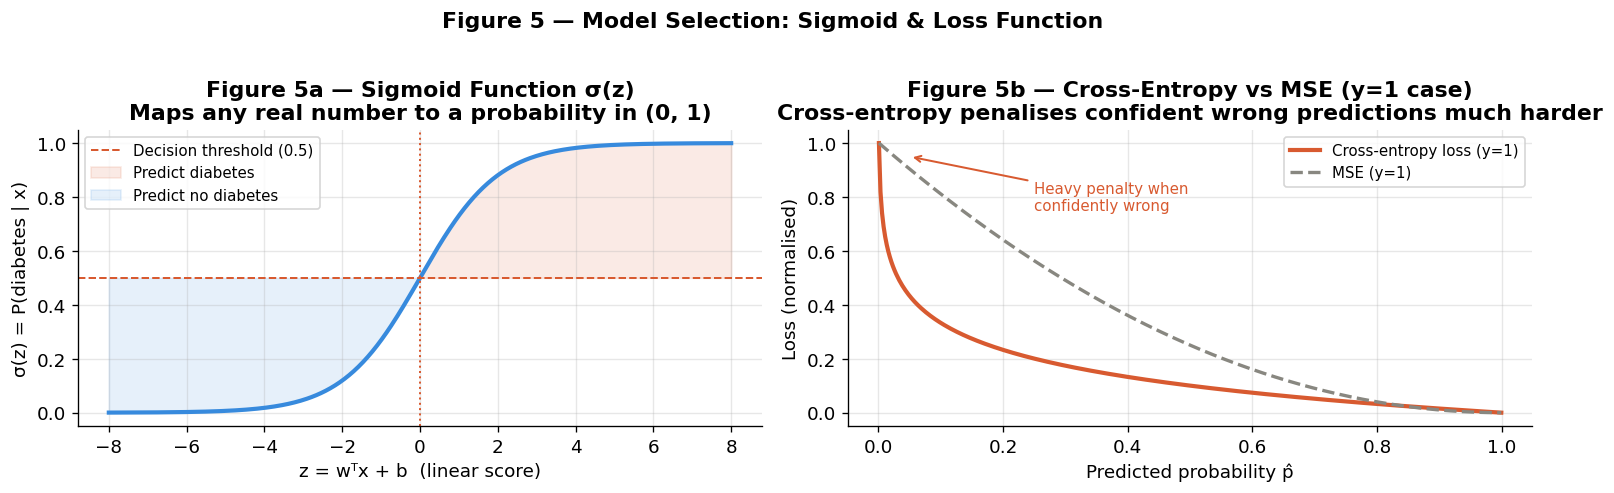

In [ ]:
# ── 6a. Visualise the sigmoid function ───────────────────────────────────────
z = np.linspace(-8, 8, 400)
sigma = 1 / (1 + np.exp(-z))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sigmoid
axes[0].plot(z, sigma, color=BLUE, linewidth=2.5)
axes[0].axhline(0.5, color=CORAL, linewidth=1.2, linestyle='--', label='Decision threshold (0.5)')
axes[0].axvline(0.0, color=CORAL, linewidth=1.2, linestyle=':')
axes[0].fill_between(z, sigma, 0.5, where=(sigma >= 0.5),
                      alpha=0.12, color=CORAL, label='Predict diabetes')
axes[0].fill_between(z, sigma, 0.5, where=(sigma < 0.5),
                      alpha=0.12, color=BLUE,  label='Predict no diabetes')
axes[0].set_title('Figure 5a — Sigmoid Function σ(z)\n'
                  'Maps any real number to a probability in (0, 1)',
                  fontweight='bold')
axes[0].set_xlabel('z = wᵀx + b  (linear score)')
axes[0].set_ylabel('σ(z) = P(diabetes | x)')
axes[0].legend(fontsize=9)
axes[0].set_ylim(-0.05, 1.05)

# Log-loss vs MSE: why cross-entropy is better for classification
p   = np.linspace(0.001, 0.999, 400)
log_loss_y1   = -np.log(p)            # cross-entropy when y=1
mse_y1        = (1 - p)**2             # MSE when y=1
# normalise both to same scale for comparison
log_loss_norm = log_loss_y1 / log_loss_y1.max()
mse_norm      = mse_y1      / mse_y1.max()

axes[1].plot(p, log_loss_norm, color=CORAL, linewidth=2.5, label='Cross-entropy loss (y=1)')
axes[1].plot(p, mse_norm,      color=GRAY,  linewidth=2,   linestyle='--', label='MSE (y=1)')
axes[1].set_title('Figure 5b — Cross-Entropy vs MSE (y=1 case)\n'
                  'Cross-entropy penalises confident wrong predictions much harder',
                  fontweight='bold')
axes[1].set_xlabel('Predicted probability p̂')
axes[1].set_ylabel('Loss (normalised)')
axes[1].legend(fontsize=9)
axes[1].annotate('Heavy penalty when\nconfidently wrong',
                  xy=(0.05, 0.95), xytext=(0.25, 0.75),
                  fontsize=9, color=CORAL,
                  arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.2))

plt.suptitle('Figure 5 — Model Selection: Sigmoid & Loss Function',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

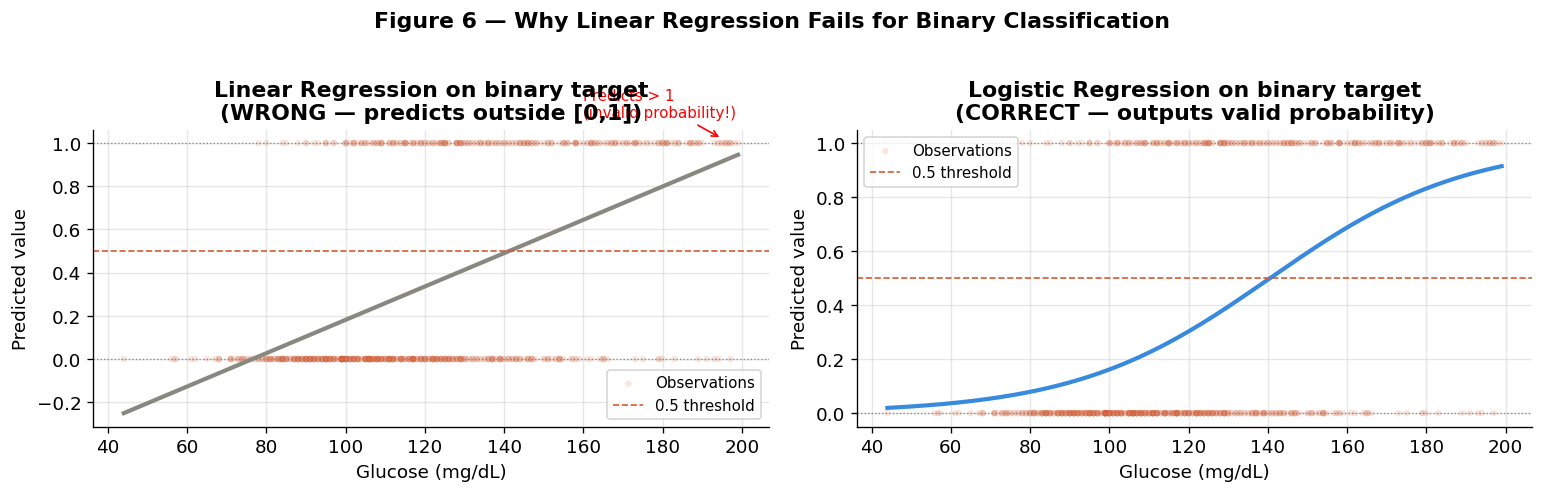

In [ ]:
# ── 6b. Show why linear regression fails on binary targets ────────────────────
from sklearn.linear_model import LinearRegression, LogisticRegression

# Use Glucose alone (strongest predictor) for 1D visualisation
x_vis = df['Glucose'].values.reshape(-1, 1)
y_vis = df['Outcome'].values

lr_bad = LinearRegression().fit(x_vis, y_vis)
log_good = LogisticRegression().fit(x_vis, y_vis)

x_range = np.linspace(df['Glucose'].min(), df['Glucose'].max(), 300).reshape(-1, 1)
y_linear = lr_bad.predict(x_range)
y_logistic = log_good.predict_proba(x_range)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, y_hat, color, title, extra in [
    (axes[0], y_linear,   GRAY,  'Linear Regression on binary target\n(WRONG — predicts outside [0,1])', True),
    (axes[1], y_logistic, BLUE,  'Logistic Regression on binary target\n(CORRECT — outputs valid probability)', False)
]:
    ax.scatter(df['Glucose'], y_vis, alpha=0.15, s=15, color=CORAL,
               edgecolors='none', label='Observations')
    ax.plot(x_range, y_hat, color=color, linewidth=2.5)
    ax.axhline(0.5, color=CORAL, linestyle='--', linewidth=1, label='0.5 threshold')
    ax.axhline(0,   color=GRAY,  linestyle=':',  linewidth=0.8)
    ax.axhline(1,   color=GRAY,  linestyle=':',  linewidth=0.8)
    if extra:
        # Annotate invalid predictions
        ax.annotate('Predicts > 1\n(invalid probability!)',
                     xy=(195, 1.02), xytext=(160, 1.12), fontsize=9, color='red',
                     arrowprops=dict(arrowstyle='->', color='red'))
    ax.set_xlabel('Glucose (mg/dL)')
    ax.set_ylabel('Predicted value')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Figure 6 — Why Linear Regression Fails for Binary Classification',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Step 7 — Model Training

We train on an 80/20 split, stratified by class (to ensure both train and test have the same class ratio).

Steps:
1. `StandardScaler` — logistic regression uses gradient descent; features on different scales slow convergence.
2. `class_weight='balanced'` — compensates for the mild class imbalance by weighting the minority class higher in the loss.
3. `C` (inverse regularisation strength) — controls how much we penalise large weights. `C=1.0` is the sklearn default.

We also do **5-fold cross-validation** on the training set to get a reliable estimate of generalisation performance before touching the test set.

In [ ]:
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.linear_model     import LogisticRegression
from sklearn.metrics          import (accuracy_score, classification_report,
                                       confusion_matrix, roc_auc_score,
                                       roc_curve, precision_recall_curve,
                                       average_precision_score, log_loss)

# ── Train / test split ────────────────────────────────────────────────────────
X = df[ENG_FEATURES]
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f'Training: {len(X_train)} | Test: {len(X_test)}')
print(f'Train class ratio: {y_train.mean():.3f} positive')
print(f'Test  class ratio: {y_test.mean():.3f} positive')

Training: 614 | Test: 154
Train class ratio: 0.349 positive
Test  class ratio: 0.351 positive


In [ ]:
# ── Build and train pipeline ──────────────────────────────────────────────────
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
                    C=1.0,
                    class_weight='balanced',
                    max_iter=1000,
                    random_state=42
               ))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_acc = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='accuracy')
cv_auc = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='roc_auc')
cv_f1  = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')

print('5-fold Stratified CV on training set:')
print(f'  Accuracy:  {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  ROC-AUC:   {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'  F1 Score:  {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')

# Final fit on full training set
pipe_lr.fit(X_train, y_train)
print('\nModel trained.')

5-fold Stratified CV on training set:
  Accuracy:  0.7703 ± 0.0168
  ROC-AUC:   0.8427 ± 0.0192
  F1 Score:  0.6953  ± 0.0185

Model trained.


---
## Step 8 — Evaluation & Tuning

For **binary classification**, accuracy alone is misleading — especially with class imbalance. A model that always predicts "no diabetes" gets 65% accuracy but is useless. We use a richer set of metrics:

| Metric | Formula | When it matters |
|---|---|---|
| **Accuracy** | $(TP+TN)/(TP+TN+FP+FN)$ | Baseline only |
| **Precision** | $TP/(TP+FP)$ | Cost of false positives is high |
| **Recall (Sensitivity)** | $TP/(TP+FN)$ | Cost of false negatives is high — **key for medical diagnosis** |
| **F1 Score** | $2 \cdot (P \cdot R)/(P+R)$ | Balanced metric for imbalanced classes |
| **ROC-AUC** | Area under ROC curve | Overall discrimination ability |
| **Log Loss** | $-\frac{1}{n}\sum[y\log\hat{p}+(1-y)\log(1-\hat{p})]$ | Quality of probability calibration |

In a medical context, **recall (sensitivity) is more important than precision** — a missed diabetic patient (false negative) is more dangerous than a false alarm (false positive).

In [ ]:
# ── Test set evaluation ───────────────────────────────────────────────────────
y_pred      = pipe_lr.predict(X_test)
y_prob      = pipe_lr.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
auc  = roc_auc_score(y_test, y_prob)
ll   = log_loss(y_test, y_prob)
ap   = average_precision_score(y_test, y_prob)

print('Test set performance:')
print(f'  Accuracy     : {acc:.4f}')
print(f'  ROC-AUC      : {auc:.4f}')
print(f'  Log Loss     : {ll:.4f}')
print(f'  Avg Precision: {ap:.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred,
                             target_names=['No diabetes', 'Diabetes']))

Test set performance:
  Accuracy     : 0.7597
  ROC-AUC      : 0.8156
  Log Loss     : 0.5305
  Avg Precision: 0.6627

Classification Report:
              precision    recall  f1-score   support

 No diabetes       0.87      0.74      0.80       100
    Diabetes       0.62      0.80      0.70        54

    accuracy                           0.76       154
   macro avg       0.75      0.77      0.75       154
weighted avg       0.78      0.76      0.76       154



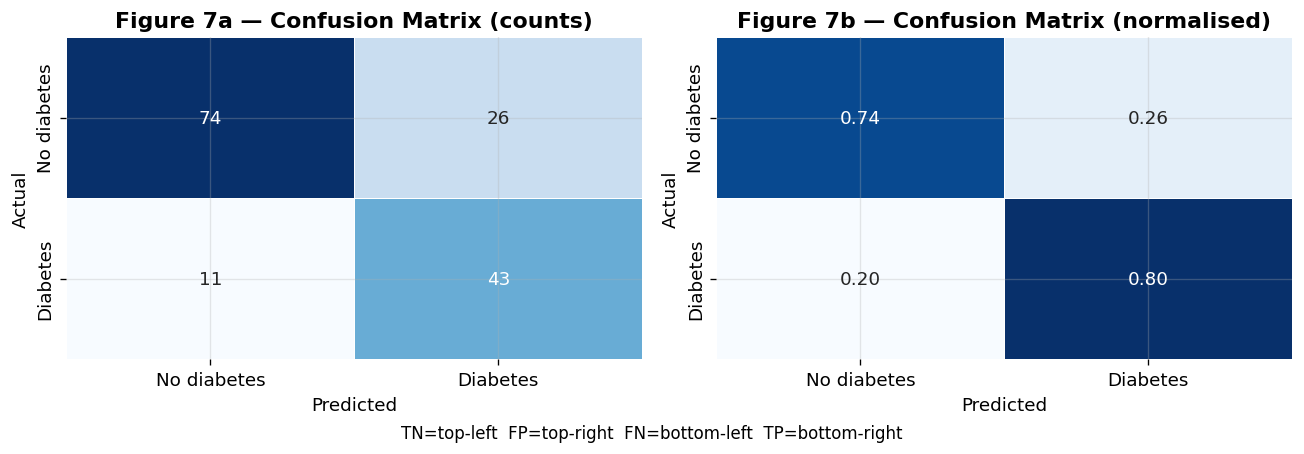

True  Negatives (correctly said no diabetes): 74
False Positives (said diabetes, actually not): 26
False Negatives (missed a diabetic patient):   11  ← most costly in medicine
True  Positives (correctly identified diabetes): 43


In [ ]:
# ── Figure 7: Confusion matrix ────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, data, fmt, title in [
    (axes[0], cm,      'd',    'Figure 7a — Confusion Matrix (counts)'),
    (axes[1], cm_norm, '.2f',  'Figure 7b — Confusion Matrix (normalised)')
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=['No diabetes', 'Diabetes'],
                yticklabels=['No diabetes', 'Diabetes'],
                linewidths=0.5, ax=ax, cbar=False)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    ax.set_title(title, fontweight='bold')

plt.suptitle('TN=top-left  FP=top-right  FN=bottom-left  TP=bottom-right',
             fontsize=10, y=0.02)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True  Negatives (correctly said no diabetes): {tn}')
print(f'False Positives (said diabetes, actually not): {fp}')
print(f'False Negatives (missed a diabetic patient):   {fn}  ← most costly in medicine')
print(f'True  Positives (correctly identified diabetes): {tp}')

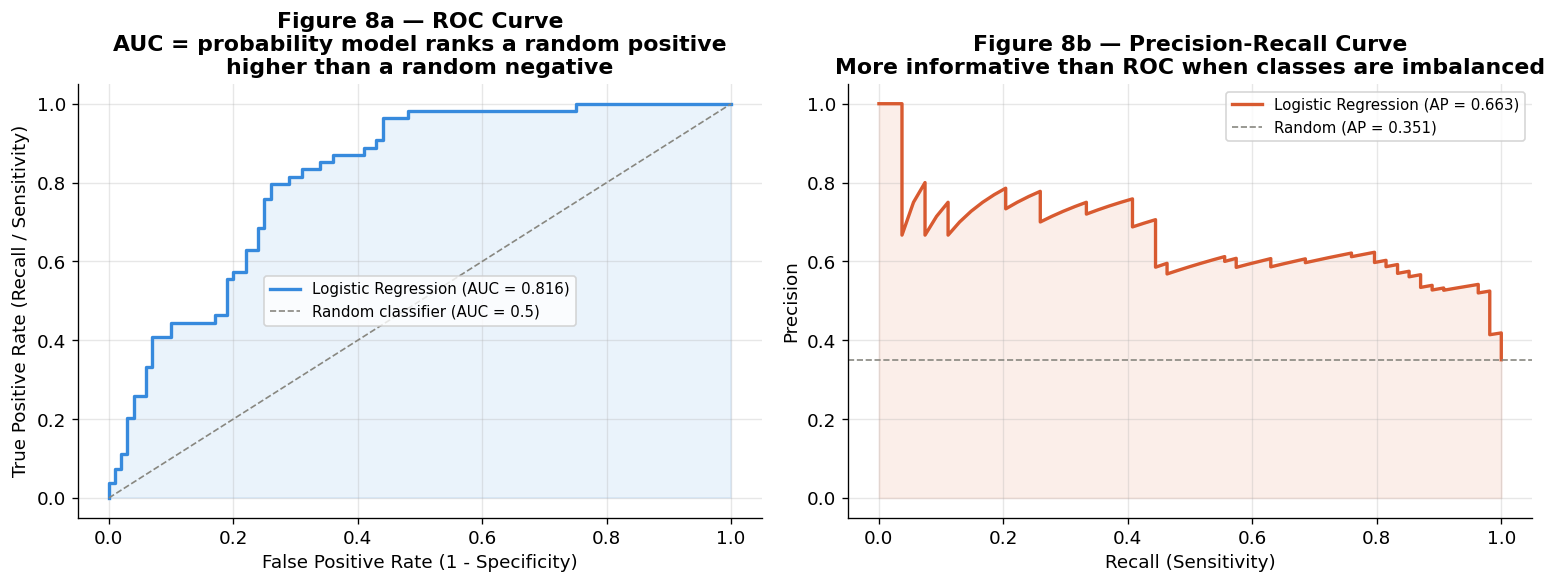

In [ ]:
# ── Figure 8: ROC curve and Precision-Recall curve ────────────────────────────
fpr, tpr, thresh_roc = roc_curve(y_test, y_prob)
prec, rec, thresh_pr = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color=BLUE, linewidth=2,
             label=f'Logistic Regression (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], color=GRAY, linewidth=1,
             linestyle='--', label='Random classifier (AUC = 0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color=BLUE)
axes[0].set_title('Figure 8a — ROC Curve\n'
                  'AUC = probability model ranks a random positive\n'
                  'higher than a random negative', fontweight='bold')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Recall / Sensitivity)')
axes[0].legend(fontsize=9)

# PR curve
baseline = y_test.mean()
axes[1].plot(rec, prec, color=CORAL, linewidth=2,
             label=f'Logistic Regression (AP = {ap:.3f})')
axes[1].axhline(baseline, color=GRAY, linewidth=1,
                linestyle='--', label=f'Random (AP = {baseline:.3f})')
axes[1].fill_between(rec, prec, alpha=0.1, color=CORAL)
axes[1].set_title('Figure 8b — Precision-Recall Curve\n'
                  'More informative than ROC when classes are imbalanced',
                  fontweight='bold')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

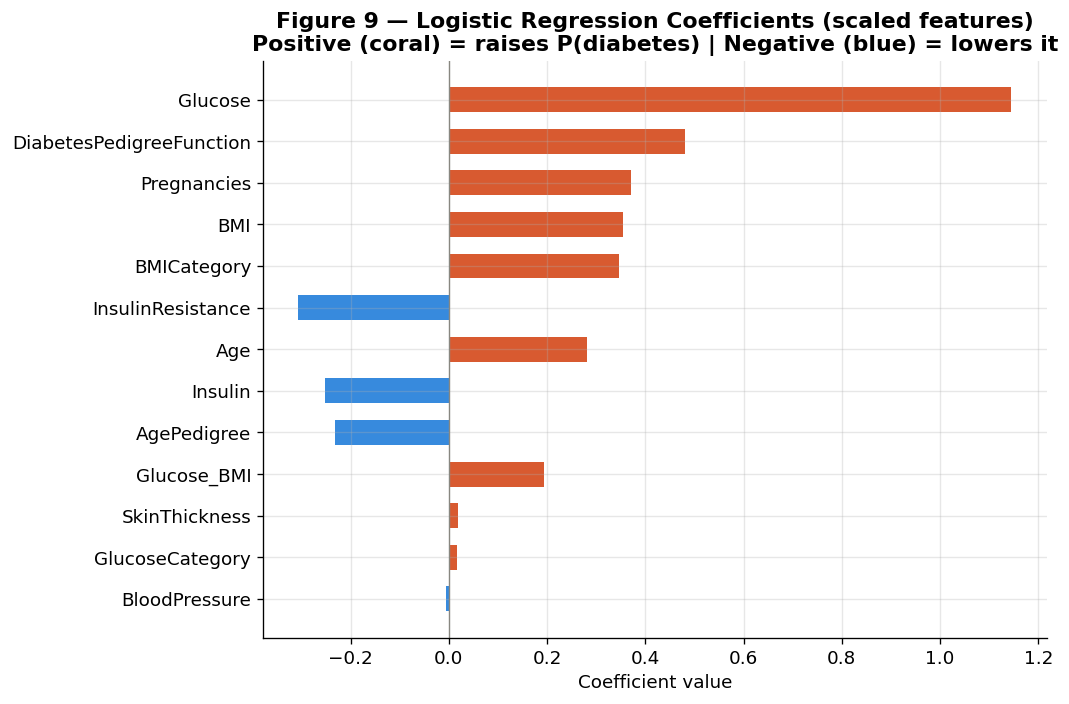

Odds ratios (exp of coefficients) — scaled features:
  OR > 1 = increases odds of diabetes
  OR < 1 = decreases odds of diabetes

  Glucose                         coef=+1.145  OR=3.141
  DiabetesPedigreeFunction        coef=+0.482  OR=1.619
  Pregnancies                     coef=+0.370  OR=1.448
  BMI                             coef=+0.355  OR=1.426
  BMICategory                     coef=+0.346  OR=1.414
  InsulinResistance               coef=-0.306  OR=0.736
  Age                             coef=+0.282  OR=1.326
  Insulin                         coef=-0.251  OR=0.778
  AgePedigree                     coef=-0.231  OR=0.793
  Glucose_BMI                     coef=+0.195  OR=1.215
  SkinThickness                   coef=+0.018  OR=1.019
  GlucoseCategory                 coef=+0.017  OR=1.017
  BloodPressure                   coef=-0.005  OR=0.995


In [ ]:
# ── Figure 9: Feature coefficients ───────────────────────────────────────────
coef    = pipe_lr.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'Feature': ENG_FEATURES, 'Coefficient': coef})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(9, 6))
colors = [CORAL if v > 0 else BLUE for v in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'],
        color=colors, edgecolor='none', height=0.6)
ax.axvline(0, color=GRAY, linewidth=0.8)
ax.invert_yaxis()
ax.set_title('Figure 9 — Logistic Regression Coefficients (scaled features)\n'
             'Positive (coral) = raises P(diabetes) | Negative (blue) = lowers it',
             fontweight='bold')
ax.set_xlabel('Coefficient value')
plt.tight_layout()
plt.show()

# Odds ratios — more interpretable clinically
print('Odds ratios (exp of coefficients) — scaled features:')
print('  OR > 1 = increases odds of diabetes')
print('  OR < 1 = decreases odds of diabetes')
print()
for feat, c in zip(coef_df['Feature'], coef_df['Coefficient']):
    print(f'  {feat:<30}  coef={c:+.3f}  OR={np.exp(c):.3f}')

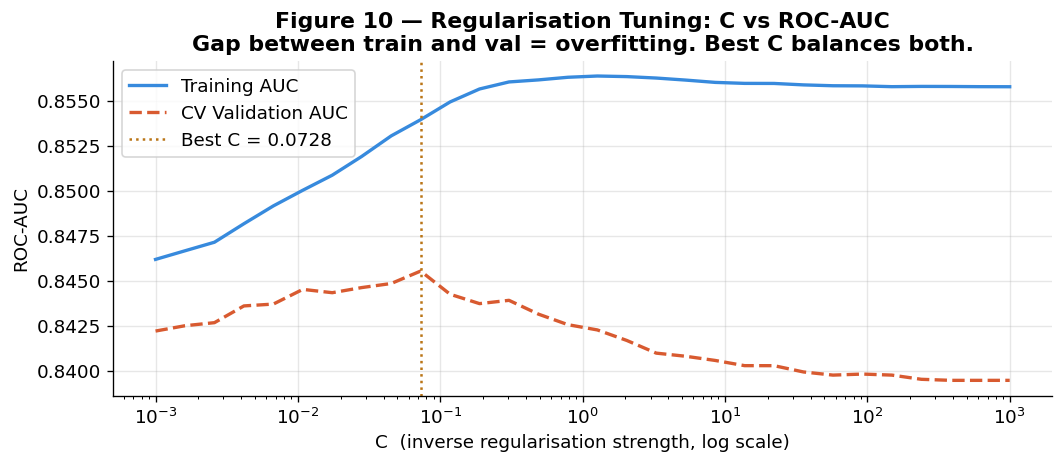

Best C from CV sweep: 0.0728


In [ ]:
from sklearn.model_selection import GridSearchCV, cross_validate

C_values = np.logspace(-3, 3, 30)
train_auc, val_auc = [], []

for C in C_values:
    pipe_c = Pipeline([
        ('sc', StandardScaler()),
        ('m',  LogisticRegression(
                    C=C,
                    class_weight='balanced',
                    max_iter=1000,
                    random_state=42
               ))
    ])

    # Use cross_validate to get both train and test scores
    cv_results = cross_validate(pipe_c, X_train, y_train, cv=cv,
                                scoring='roc_auc', return_train_score=True)

    train_auc.append(cv_results['train_score'].mean())
    val_auc.append(cv_results['test_score'].mean())

best_C = C_values[np.argmax(val_auc)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(C_values, train_auc, color=BLUE,  linewidth=2,
             label='Training AUC')
ax.semilogx(C_values, val_auc,   color=CORAL, linewidth=2,
             linestyle='--', label='CV Validation AUC')
ax.axvline(best_C, color=AMBER, linewidth=1.5,
            linestyle=':', label=f'Best C = {best_C:.4f}')
ax.set_title('Figure 10 — Regularisation Tuning: C vs ROC-AUC\n'
             'Gap between train and val = overfitting. Best C balances both.',
             fontweight='bold')
ax.set_xlabel('C  (inverse regularisation strength, log scale)')
ax.set_ylabel('ROC-AUC')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best C from CV sweep: {best_C:.4f}')

In [ ]:
# ── Final model with best C ───────────────────────────────────────────────────
pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(C=best_C, class_weight='balanced',
                                   max_iter=1000, random_state=42))
])
pipe_final.fit(X_train, y_train)
y_pred_f = pipe_final.predict(X_test)
y_prob_f = pipe_final.predict_proba(X_test)[:, 1]

print(f'Final model (C={best_C:.4f}) — Test set:')
print(f'  Accuracy : {accuracy_score(y_test, y_pred_f):.4f}')
print(f'  ROC-AUC  : {roc_auc_score(y_test, y_prob_f):.4f}')
print(f'  Log Loss : {log_loss(y_test, y_prob_f):.4f}')
print()
print(classification_report(y_test, y_pred_f,
                              target_names=['No diabetes', 'Diabetes']))

Final model (C=0.0728) — Test set:
  Accuracy : 0.7403
  ROC-AUC  : 0.8174
  Log Loss : 0.5248

              precision    recall  f1-score   support

 No diabetes       0.84      0.74      0.79       100
    Diabetes       0.61      0.74      0.67        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.76      0.74      0.74       154



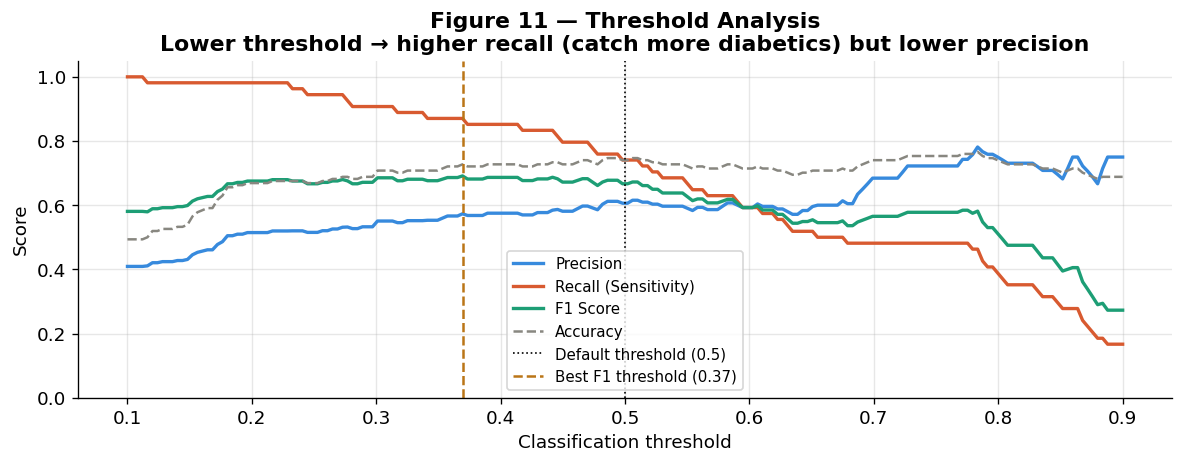

Default threshold (0.5): Recall=0.741, Precision=0.606
Best F1  threshold (0.37): Recall=0.870, Precision=0.573


In [ ]:
# ── Figure 11: Threshold analysis — precision vs recall tradeoff ───────────────
# In medicine, we might prefer higher recall (catch more diabetics)
# at the cost of lower precision (more false alarms)
thresholds = np.linspace(0.1, 0.9, 200)
precisions, recalls, f1s, accs = [], [], [], []

from sklearn.metrics import precision_score, recall_score, f1_score

for t in thresholds:
    y_t = (y_prob_f >= t).astype(int)
    if y_t.sum() == 0:
        precisions.append(0); recalls.append(0); f1s.append(0); accs.append(0)
        continue
    precisions.append(precision_score(y_test, y_t, zero_division=0))
    recalls.append(recall_score(y_test, y_t))
    f1s.append(f1_score(y_test, y_t, zero_division=0))
    accs.append(accuracy_score(y_test, y_t))

best_f1_thresh = thresholds[np.argmax(f1s)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, precisions, color=BLUE,  linewidth=2, label='Precision')
ax.plot(thresholds, recalls,    color=CORAL, linewidth=2, label='Recall (Sensitivity)')
ax.plot(thresholds, f1s,        color=TEAL,  linewidth=2, label='F1 Score')
ax.plot(thresholds, accs,       color=GRAY,  linewidth=1.5, linestyle='--', label='Accuracy')
ax.axvline(0.5,           color='black', linewidth=1,   linestyle=':',  label='Default threshold (0.5)')
ax.axvline(best_f1_thresh, color=AMBER,  linewidth=1.5, linestyle='--', label=f'Best F1 threshold ({best_f1_thresh:.2f})')
ax.set_title('Figure 11 — Threshold Analysis\n'
             'Lower threshold → higher recall (catch more diabetics) but lower precision',
             fontweight='bold')
ax.set_xlabel('Classification threshold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Default threshold (0.5): Recall={recalls[100]:.3f}, Precision={precisions[100]:.3f}')
print(f'Best F1  threshold ({best_f1_thresh:.2f}): Recall={recalls[np.argmax(f1s)]:.3f}, '
      f'Precision={precisions[np.argmax(f1s)]:.3f}')

---
## Step 9 — PCA Extension

We apply PCA as discussed in the supplementary PCA notebook, and show the decision boundary visually in 2D.

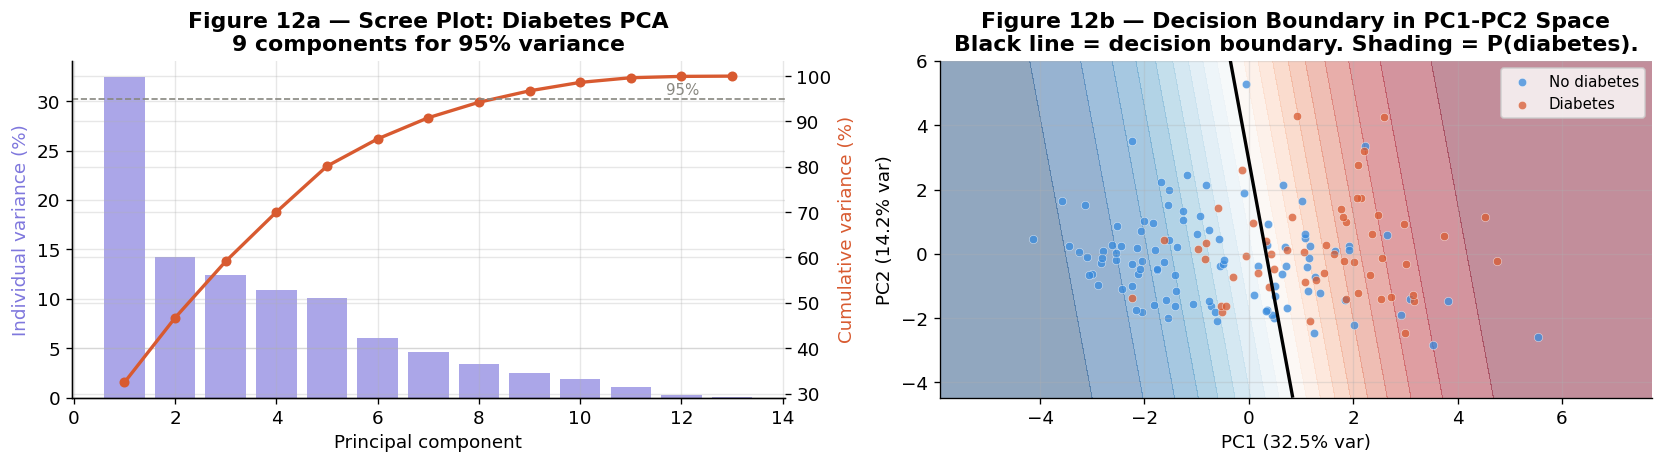

Comparison: with vs without PCA
  Without PCA → AUC: 0.8174
  With    PCA → AUC: 0.8165


In [ ]:
from sklearn.decomposition import PCA

# ── Scree plot ────────────────────────────────────────────────────────────────
scaler_pca = StandardScaler()
X_tr_sc    = scaler_pca.fit_transform(X_train)
pca_full   = PCA().fit(X_tr_sc)
evr        = pca_full.explained_variance_ratio_
cumv       = np.cumsum(evr)
k_pca      = np.argmax(cumv >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax2 = axes[0].twinx()
axes[0].bar(range(1, len(evr)+1), evr*100, color=PURP, alpha=0.65)
ax2.plot(range(1, len(evr)+1), cumv*100, color=CORAL,
          marker='o', markersize=5, linewidth=2)
ax2.axhline(95, color=GRAY, linewidth=1, linestyle='--')
ax2.text(len(evr)*0.95, 96, '95%', ha='right', fontsize=9, color=GRAY)
axes[0].set_title(f'Figure 12a — Scree Plot: Diabetes PCA\n'
                   f'{k_pca} components for 95% variance', fontweight='bold')
axes[0].set_xlabel('Principal component')
axes[0].set_ylabel('Individual variance (%)', color=PURP)
ax2.set_ylabel('Cumulative variance (%)', color=CORAL)

# Decision boundary in PC1-PC2 space
pca_2d  = PCA(n_components=2)
X_tr_2d = pca_2d.fit_transform(X_tr_sc)
X_te_2d = pca_2d.transform(scaler_pca.transform(X_test))

lr_2d = LogisticRegression(C=best_C, class_weight='balanced',
                             max_iter=1000, random_state=42)
lr_2d.fit(X_tr_2d, y_train)

xx, yy = np.meshgrid(
    np.linspace(X_tr_2d[:, 0].min()-0.5, X_tr_2d[:, 0].max()+0.5, 300),
    np.linspace(X_tr_2d[:, 1].min()-0.5, X_tr_2d[:, 1].max()+0.5, 300)
)
Z = lr_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

axes[1].contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.45)
axes[1].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
for cls, col, lbl in [(0, BLUE, 'No diabetes'), (1, CORAL, 'Diabetes')]:
    m = y_test.values == cls
    axes[1].scatter(X_te_2d[m, 0], X_te_2d[m, 1],
                     c=col, s=25, alpha=0.75, label=lbl,
                     edgecolors='white', linewidths=0.3)
axes[1].set_title('Figure 12b — Decision Boundary in PC1-PC2 Space\n'
                   'Black line = decision boundary. Shading = P(diabetes).',
                   fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Compare with-PCA vs without-PCA
pipe_pca = Pipeline([
    ('sc',  StandardScaler()),
    ('pca', PCA(n_components=k_pca)),
    ('m',   LogisticRegression(C=best_C, class_weight='balanced',
                                max_iter=1000, random_state=42))
])
pipe_pca.fit(X_train, y_train)
y_prob_pca = pipe_pca.predict_proba(X_test)[:, 1]

print('Comparison: with vs without PCA')
print(f'  Without PCA → AUC: {roc_auc_score(y_test, y_prob_f):.4f}')
print(f'  With    PCA → AUC: {roc_auc_score(y_test, y_prob_pca):.4f}')

---
## Summary

| Step | Key output |
|---|---|
| Problem | Binary classification: diabetes (1) vs no diabetes (0) |
| Dataset | Pima Indians Diabetes, 768 patients, 8 features |
| Key preprocessing | Replace physiological zeros with median; `class_weight='balanced'` |
| Engineered features | `GlucoseCategory`, `BMICategory`, `Glucose_BMI`, `InsulinResistance`, `AgePedigree` |
| Model chosen | **Logistic Regression** |
| Core justification | Binary output → sigmoid maps score to valid probability; cross-entropy is convex (unlike MSE on sigmoid); linear decision boundary; interpretable coefficients as odds ratios |
| Regularisation | L2 via `C` parameter, tuned by CV sweep |
| Key metric | ROC-AUC (because recall > precision in medical diagnosis) |
| Threshold tuning | Lower threshold raises recall — catches more diabetic patients |

**The core mathematical argument:**

$$P(\text{diabetes} \mid \mathbf{x}) = \frac{1}{1+e^{-(\mathbf{w}^T\mathbf{x}+b)}}$$

$$\text{Minimise: } \mathcal{L}(\mathbf{w}) = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log\hat{p}_i + (1-y_i)\log(1-\hat{p}_i)\right]$$

$$\text{Gradient: } \frac{\partial\mathcal{L}}{\partial\mathbf{w}} = \frac{1}{n}X^T(\hat{\mathbf{p}} - \mathbf{y}) \quad \leftarrow \text{convex, one global minimum}$$

---
*Next: Problem 3 — Loan Approval with Decision Trees*